# Landing Fuel Prediction using XGBoost

Goal:
Predict fuel consumption during the landing phase using ADS-B derived flight phase features.

### Imports

In [133]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import sqlite3


### Load feature dataset

The landing-phase feature table is loaded from the SQLite database.
Each row represents one flight with aggregated phase-level features.

Target variable:
- landing_fuel

Input features:
- landing duration
- landing distance 
- mean ground speed
- mean vertical rate
- turning intensity
- route distance

These features are physically motivated and describe the landing
energy and flight profile.

In [ ]:
DB_PATH = "../opensky.sqlite"
FEATURE_TABLE = "flight_phase_features_physics_weather"
YEAR = 2022

TARGET = "landing_fuel"

FEATURES = [
    "time_s_landing",
    "dist_m_landing",
    "mean_gs_mps_landing",
    "p95_gs_mps_landing",
    "mean_vr_mps_landing",
    "turn_sum_deg_landing",
    "great_circle_distance",
    "alt_loss_m_landing",
    "mean_alt_m_landing",
    "max_alt_m_landing",
    "alt_gain_m_landing",
    "descent_rate_landing",
    #"spec_pe_landing",
    #"spec_ke_landing",
    "gradient_landing",
    "turn_rate_degps_landing",
    #"dyn_press_landing",
    #"drag_work_landing"

    # weather
    "arr_temp_mean",
    "arr_wind_speed_mean",
    "arr_headwind",
    "arr_crosswind",

    # time features
    "arr_hour_sin", "arr_hour_cos",
    "arr_dow_sin", "arr_dow_cos", 
    "dep_month_sin", "dep_month_cos"

  
]

### Reconstruct flight dataframe

The dataset does not contain an explicit datetime column.
Instead, the flight timestamp is reconstructed from the `flight_id`,
which follows the format:

    icao24-callsign-mm-dd-hh-mm

The flight date and time are parsed and converted into a proper
datetime object (`flight_dt`), which is used for temporal splitting.
This ensures a leakage-safe separation between training and test data. 
We also define evaluation metrics (MAE, MAPE).


In [135]:
def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.split("-", expand=True)
    if parts.shape[1] < 6:
        raise ValueError("flight_id must be: icao24-callsign-mm-dd-hh-mm")

    month  = parts[2].astype(int)
    day    = parts[3].astype(int)
    hour   = parts[4].astype(int)
    minute = parts[5].astype(int)

    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {"year": year, "month": month, "day": day, "hour": hour, "minute": minute},
        errors="coerce"
    )
    return out


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100


def make_X(dfx: pd.DataFrame) -> pd.DataFrame:
    return dfx[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)




### Load feature table from SQLite

In [136]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()

print("Rows total:", len(df))
df.head(3)

Rows total: 14015


,flight_id,icao24,callsign,aircraft_type_icao_code,estdepartureairport,estarrivalairport,great_circle_distance,dep_time,arr_time,time_s_takeoff,...,dep_hour_cos,dep_month_sin,dep_month_cos,dep_dow_sin,dep_dow_cos,arr_hour_sin,arr_hour_cos,arr_dow_sin,arr_dow_cos,flight_dt
0,4784c2-NOZ132-10-10-13-51,4784c2,NOZ132,B738,ENBR,ENZV,159630.0,1.665410e+09,1.665411e+09,40.0,...,-0.965926,-0.866025,0.5,0.000000,1.000000,-0.500000,-0.866025,0.000000,1.000000,2022-10-10 13:51:00
1,4784c2-NOZ132-10-12-13-57,4784c2,NOZ132,B738,ENBR,ENZV,159630.0,1.665583e+09,1.665584e+09,50.0,...,-0.965926,-0.866025,0.5,0.974928,-0.222521,-0.500000,-0.866025,0.974928,-0.222521,2022-10-12 13:57:00
2,4784c2-NOZ133-10-10-14-49,4784c2,NOZ133,B738,ENZV,ENBR,159630.0,1.665413e+09,1.665415e+09,90.0,...,-0.866025,-0.866025,0.5,0.000000,1.000000,-0.707107,-0.707107,0.000000,1.000000,2022-10-10 14:49:00


### Filter to valid landing samples


Keep only flights with:
- valid timestamp
- valid target
- positive landing time and distance

In [137]:
df2 = df[df["flight_dt"].notna()].copy()
df2 = df2[df2[TARGET].notna()].copy()

# must have landing phase
df2 = df2[df2["time_s_landing"].fillna(0.0) > 0.0].copy()
df2 = df2[df2["dist_m_landing"].fillna(0.0) > 0.0].copy()
df2["month"] = df2["flight_dt"].dt.month


print("Filtered rows:", len(df2))

Filtered rows: 13984


### Temporal Data Split

We split the dataset into:

- Development period: January–October  
- Test period: November–December  

The development period is used for time-based cross-validation and hyperparameter selection.

The test period remains completely unseen until final evaluation to ensure an unbiased estimate of model performance.

In [138]:
dev  = df2[df2["month"] <= 10].copy()   # Jan–Oct
test = df2[df2["month"] >= 11].copy()   # Nov–Dec

print("Development:", len(dev), "| Test:", len(test))

dev["descent_rate_landing"] = dev["alt_loss_m_landing"] / dev["time_s_landing"].clip(lower=1)
test["descent_rate_landing"] = test["alt_loss_m_landing"] / test["time_s_landing"].clip(lower=1)

Development: 10484 | Test: 3500


### Walk-forward 5-Fold Cross-Validation with early stopping
To evaluate model performance in a temporally consistent manner, a walk-forward
cross-validation scheme is applied on the training period.

The training data is divided into five chronological folds. For each fold,
the model is trained on all earlier time periods and evaluated on the next
time segment. This ensures that the model is always tested on future data
relative to its training data.

Within each fold, an internal validation split (grouped by aircraft `icao24`)
is used for early stopping to reduce overfitting.

Performance is reported using MAE and MAPE across folds.


In [139]:
K = 5


df_cv = dev.sort_values("flight_dt").reset_index(drop=True).copy()
df_cv["time_fold"] = pd.qcut(
    df_cv["flight_dt"].rank(method="first"),
    q=K,
    labels=False
)

fold_mae, fold_mape, best_iters = [], [], []

for fold in range(1, K):
    train_fold = df_cv[df_cv["time_fold"] < fold].copy()
    test_fold  = df_cv[df_cv["time_fold"] == fold].copy()

    gss = GroupShuffleSplit(test_size=0.2, random_state=42)
    tr_idx, va_idx = next(gss.split(train_fold, groups=train_fold["icao24"]))

    tr = train_fold.iloc[tr_idx]
    va = train_fold.iloc[va_idx]

    X_tr = tr[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y_tr = tr[TARGET].to_numpy()

    X_va = va[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y_va = va[TARGET].to_numpy()

    X_te = test_fold[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y_te = test_fold[TARGET].to_numpy()

    model = XGBRegressor(
        n_estimators=12000,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        min_child_weight=1,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=200,
        eval_metric="mae",
        objective="reg:squarederror",
    )

    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, pred)
    mp  = mape(y_te, pred)

    fold_mae.append(mae)
    fold_mape.append(mp)
    best_iters.append(model.best_iteration)

    print(f"Fold {fold}/{K} | MAE={mae:.2f} | MAPE={mp:.2f}% | best_iter={model.best_iteration}")

print("\nCV summary")
print(f"Mean MAE : {np.mean(fold_mae):.2f} ± {np.std(fold_mae):.2f}")
print(f"Mean MAPE: {np.mean(fold_mape):.2f}%")
avg_best_iter = int(np.mean(best_iters))
print(f"Avg best_iter: {avg_best_iter}")

Fold 1/5 | MAE=2.20 | MAPE=26.12% | best_iter=78
Fold 2/5 | MAE=2.31 | MAPE=24.03% | best_iter=100
Fold 3/5 | MAE=2.11 | MAPE=25.75% | best_iter=194
Fold 4/5 | MAE=2.73 | MAPE=34.54% | best_iter=95

CV summary
Mean MAE : 2.34 ± 0.24
Mean MAPE: 27.61%
Avg best_iter: 116


### Final model training and evaluation

After cross-validation, we compute the average optimal number of boosting rounds.

We then train a final model on all available pre-test data (training + validation months) using this fixed number of estimators.

No early stopping is used at this stage, as model complexity has already been selected during cross-validation.

We evaluate the final model on the held-out test set (November–December).

Performance metrics include:
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)

In [140]:
X_train_all = make_X(dev)
y_train_all = dev[TARGET].to_numpy()

final_model = XGBRegressor(
    n_estimators=avg_best_iter,
    learning_rate=0.03,   
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric="mae",
    objective="reg:squarederror",
)

final_model.fit(X_train_all, y_train_all)

X_test = make_X(test)
y_test = test[TARGET].to_numpy()

pred_test = final_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, pred_test)
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_test)

print("FINAL TEST")
print(f"MAE : {mae:.4f}")
print(f"MAPE: {mape(y_test, pred_test):.2f}%")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")




FINAL TEST
MAE : 3.1124
MAPE: 34.06%
MSE : 18.6491
RMSE: 4.3185
R²  : 0.0291


### Feature importance (sanity check)

Feature importance is extracted from the trained XGBoost model to inspect
which landing-phase variables contributed most to the predictions.


In [141]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp

dep_month_cos              0.102628
arr_crosswind              0.072458
mean_alt_m_landing         0.068995
max_alt_m_landing          0.062167
gradient_landing           0.051763
arr_headwind               0.051024
great_circle_distance      0.050992
dep_month_sin              0.050653
arr_wind_speed_mean        0.050252
arr_temp_mean              0.050100
descent_rate_landing       0.049803
p95_gs_mps_landing         0.047913
turn_rate_degps_landing    0.044990
mean_gs_mps_landing        0.042111
turn_sum_deg_landing       0.041952
mean_vr_mps_landing        0.039781
alt_loss_m_landing         0.039332
dist_m_landing             0.031758
alt_gain_m_landing         0.028702
time_s_landing             0.022626
dtype: float32

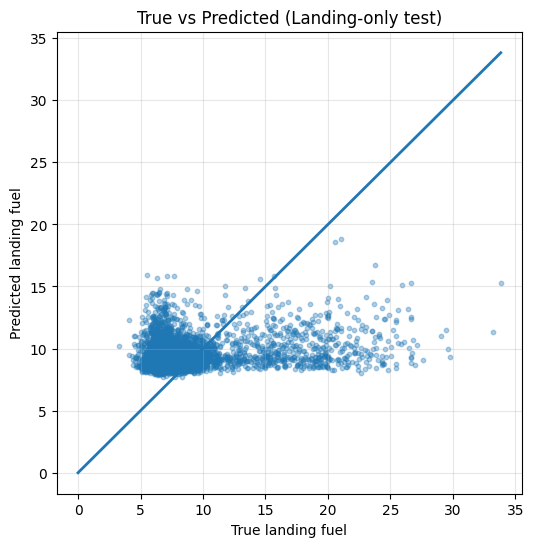

In [142]:
from matplotlib import pyplot as plt


eval_df = test[["flight_id", TARGET]].copy()
eval_df["fuel_true"] = eval_df[TARGET]
eval_df["fuel_pred"] = pred_test
eval_df["abs_err"] = np.abs(eval_df["fuel_pred"] - eval_df["fuel_true"])
plot = plt.figure(figsize=(6,6))
plt.scatter(eval_df["fuel_true"], eval_df["fuel_pred"], alpha=0.35, s=10)
mx = max(eval_df["fuel_true"].max(), eval_df["fuel_pred"].max())
plt.plot([0, mx], [0, mx], linewidth=2)  # y=x line
plt.xlabel("True landing fuel")
plt.ylabel("Predicted landing fuel")
plt.title("True vs Predicted (Landing-only test)")
plt.grid(True, alpha=0.3)


In [143]:
from pathlib import Path


csv_folder = Path("csv_files")

file_path = csv_folder / "pred_physics_landing.csv"
X_te = test[FEATURES].fillna(0.0)
pred = model.predict(X_te)

pred_df = pd.DataFrame({
    "flight_id": test["flight_id"].values,
    "pred_physics_landing": pred
})
pred_df.to_csv(file_path, index=False)